In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Successful!")

Setup Successful!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")

In [3]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

In [4]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
trades.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [12]:
sentiment.describe(include="all")

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [13]:
print("Trade Duplicates:", trades.duplicated().sum())
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trade Duplicates: 0
Sentiment Duplicates: 0


In [14]:
print(trades.dtypes)

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [15]:
print(sentiment.dtypes)

timestamp          int64
value              int64
classification    object
date              object
dtype: object


In [16]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [17]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


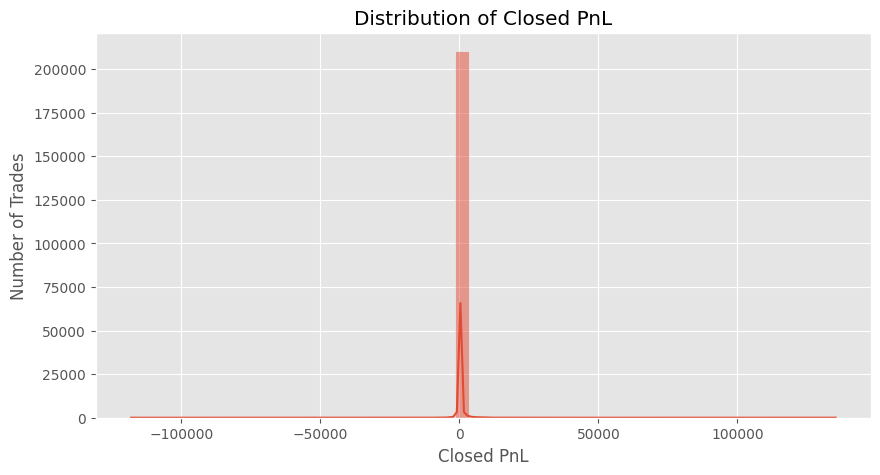

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(trades["Closed PnL"], bins=50, kde=True)
plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Number of Trades")
plt.show()

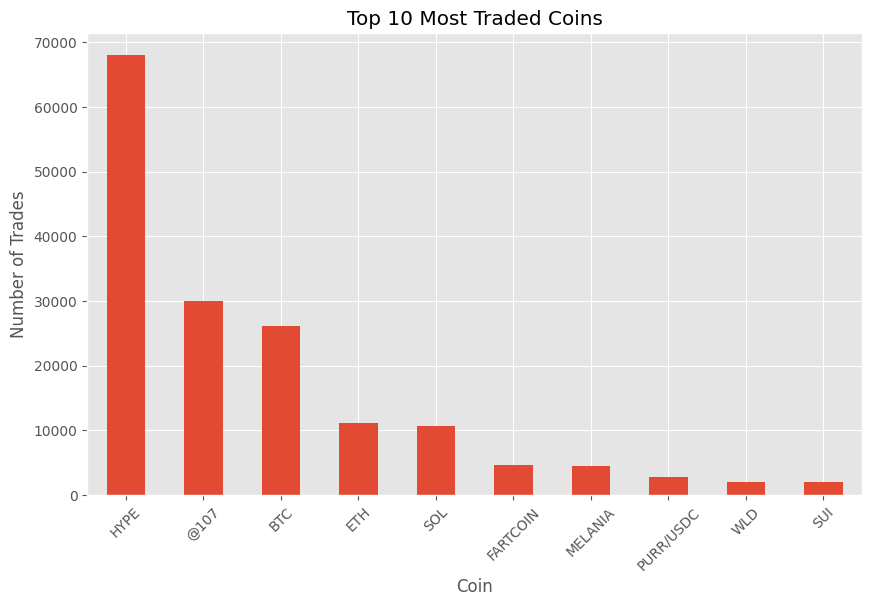

In [19]:
plt.figure(figsize=(10,6))

trades["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

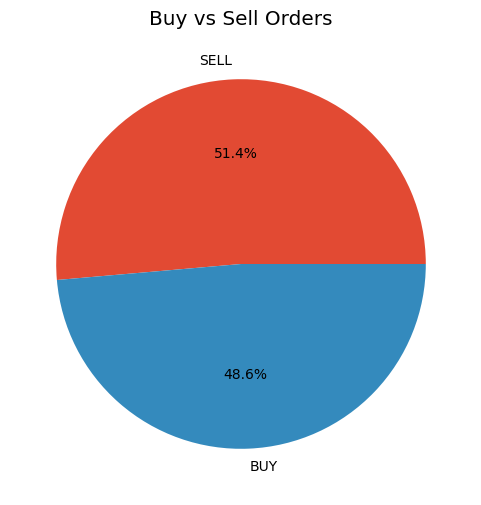

In [20]:
plt.figure(figsize=(6,6))

trades["Side"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Buy vs Sell Orders")

plt.show()

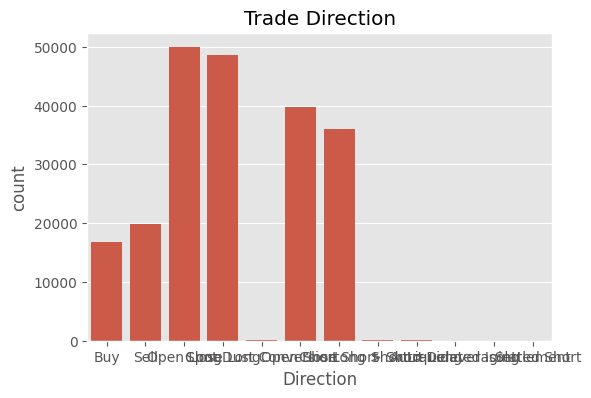

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(data=trades, x="Direction")

plt.title("Trade Direction")
plt.show()

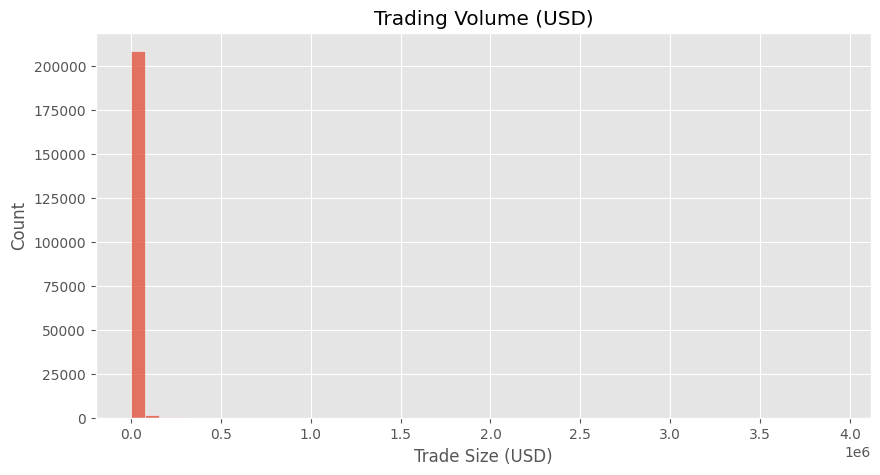

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(trades["Size USD"], bins=50)

plt.title("Trading Volume (USD)")
plt.xlabel("Trade Size (USD)")

plt.show()

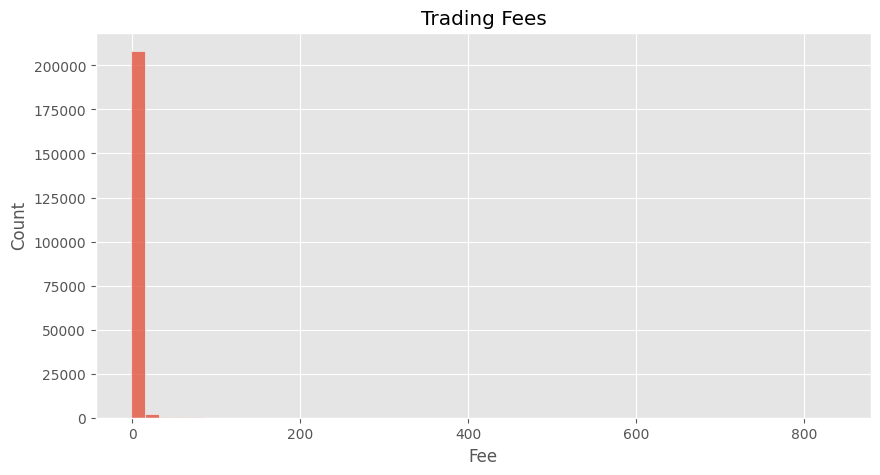

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(trades["Fee"], bins=50)

plt.title("Trading Fees")
plt.show()

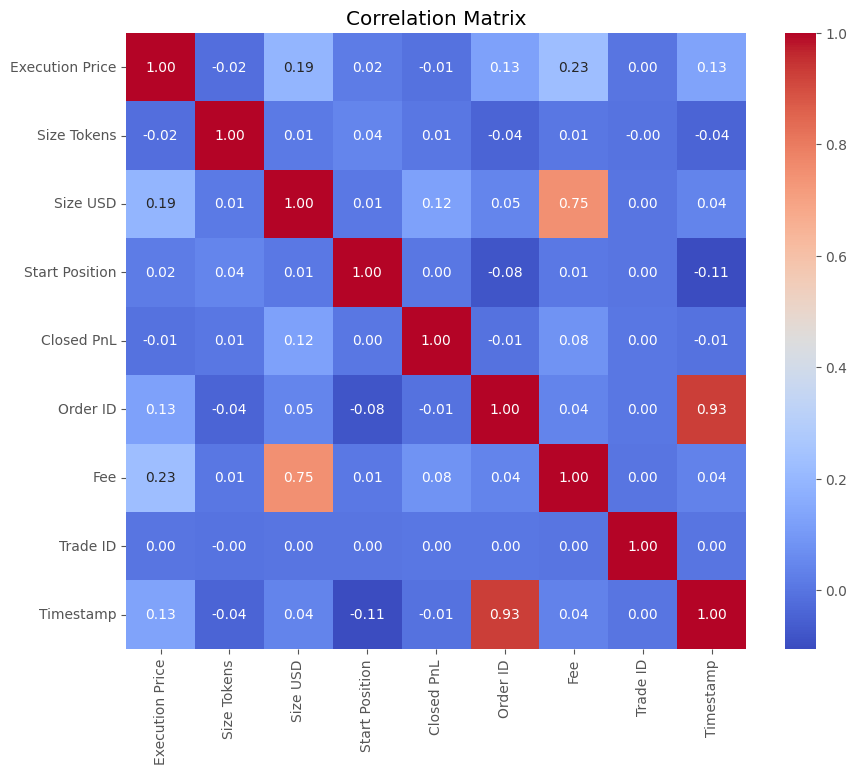

In [24]:
plt.figure(figsize=(10,8))

numeric_cols = trades.select_dtypes(include="number")

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(data=sentiment, x="Classification")

plt.xticks(rotation=45)

plt.title("Fear & Greed Distribution")

plt.show()

ValueError: Could not interpret value `Classification` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(sentiment["Value"], bins=30)

plt.title("Fear & Greed Index")

plt.show()

KeyError: 'Value'

<Figure size 1000x500 with 0 Axes>

In [27]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [28]:
trades["Date"] = trades["Timestamp IST"].dt.date

AttributeError: Can only use .dt accessor with datetimelike values

In [29]:
daily_trades = trades.groupby("Date").size()

plt.figure(figsize=(15,5))

daily_trades.plot()

plt.title("Daily Number of Trades")
plt.xlabel("Date")
plt.ylabel("Trades")

plt.show()

KeyError: 'Date'

In [30]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

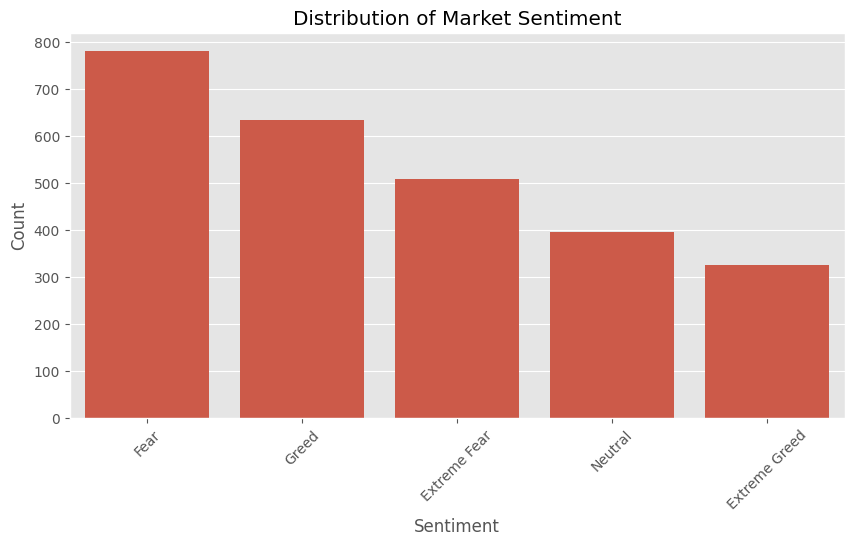

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=sentiment,
    x="classification",
    order=sentiment["classification"].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

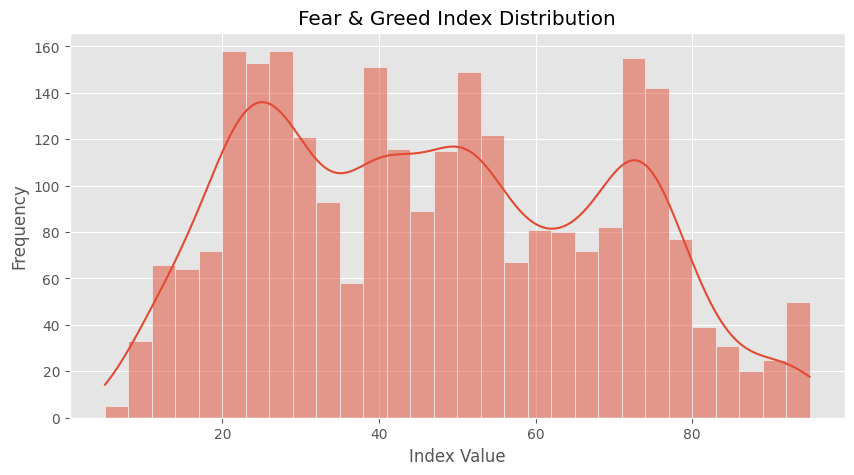

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(sentiment["value"], bins=30, kde=True)

plt.title("Fear & Greed Index Distribution")
plt.xlabel("Index Value")
plt.ylabel("Frequency")

plt.show()

In [33]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])
trades["Date"] = trades["Timestamp IST"].dt.date

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [34]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [35]:
merged = trades.merge(
    sentiment,
    left_on="Date",
    right_on="date",
    how="left"
)

KeyError: 'Date'

In [36]:
merged.head()

NameError: name 'merged' is not defined

In [37]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])
trades["Date"] = trades["Timestamp IST"].dt.date

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [38]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [39]:
merged = pd.merge(
    trades,
    sentiment,
    left_on="Date",
    right_on="date",
    how="left"
)

KeyError: 'Date'

In [40]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [41]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])
trades["Date"] = trades["Timestamp IST"].dt.date

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [42]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

In [43]:
trades["Date"] = trades["Timestamp IST"].dt.date

In [44]:
trades[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [45]:
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

In [46]:
sentiment[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [47]:
merged = pd.merge(
    trades,
    sentiment,
    on="Date",
    how="left"
)

In [48]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [49]:
merged.shape

(211224, 21)

In [50]:
sentiment.head()

,timestamp,value,classification,date,Date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [51]:
print("Trades Date Range:")
print(trades["Date"].min())
print(trades["Date"].max())

print("\nSentiment Date Range:")
print(sentiment["Date"].min())
print(sentiment["Date"].max())

Trades Date Range:
2023-05-01
2025-05-01

Sentiment Date Range:
2018-02-01
2025-05-02


In [52]:
merged[["Date", "classification", "value"]].head(10)

,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0
5,2024-12-02,Extreme Greed,80.0
6,2024-12-02,Extreme Greed,80.0
7,2024-12-02,Extreme Greed,80.0
8,2024-12-02,Extreme Greed,80.0
9,2024-12-02,Extreme Greed,80.0


In [53]:
merged["classification"].isnull().sum()

np.int64(6)

In [54]:
print(trades["Date"].min(), trades["Date"].max())
print(sentiment["Date"].min(), sentiment["Date"].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [55]:
merged = pd.merge(
    trades,
    sentiment[["Date", "value", "classification"]],
    on="Date",
    how="left"
)

In [56]:
merged.shape

(211224, 19)

In [57]:
merged[["Date", "Coin", "Closed PnL", "classification", "value"]].head()

,Date,Coin,Closed PnL,classification,value
0,2024-12-02,@107,0.0,Extreme Greed,80.0
1,2024-12-02,@107,0.0,Extreme Greed,80.0
2,2024-12-02,@107,0.0,Extreme Greed,80.0
3,2024-12-02,@107,0.0,Extreme Greed,80.0
4,2024-12-02,@107,0.0,Extreme Greed,80.0


In [58]:
merged["classification"].isnull().sum()

np.int64(6)

In [59]:
merged = merged.dropna(subset=["classification"])

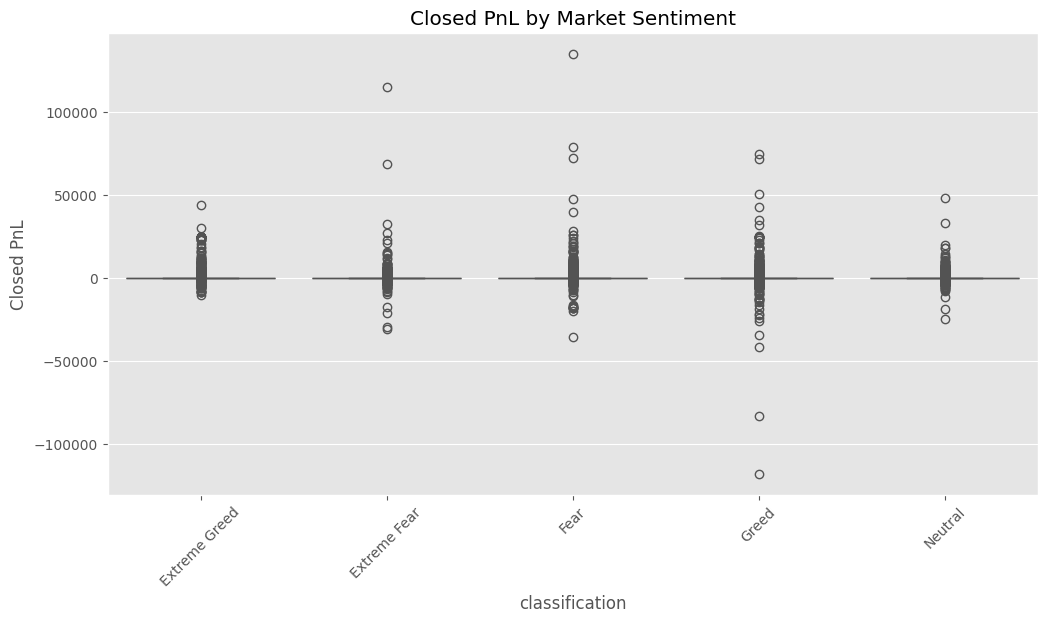

In [60]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.xticks(rotation=45)
plt.title("Closed PnL by Market Sentiment")
plt.show()

In [61]:
merged.groupby("classification")["Closed PnL"].agg(
    ["count", "mean", "median", "sum"]
).sort_values("mean", ascending=False)

,count,mean,median,sum
classification,,,,
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Neutral,37686,34.307718,0.0,1.292921e+06


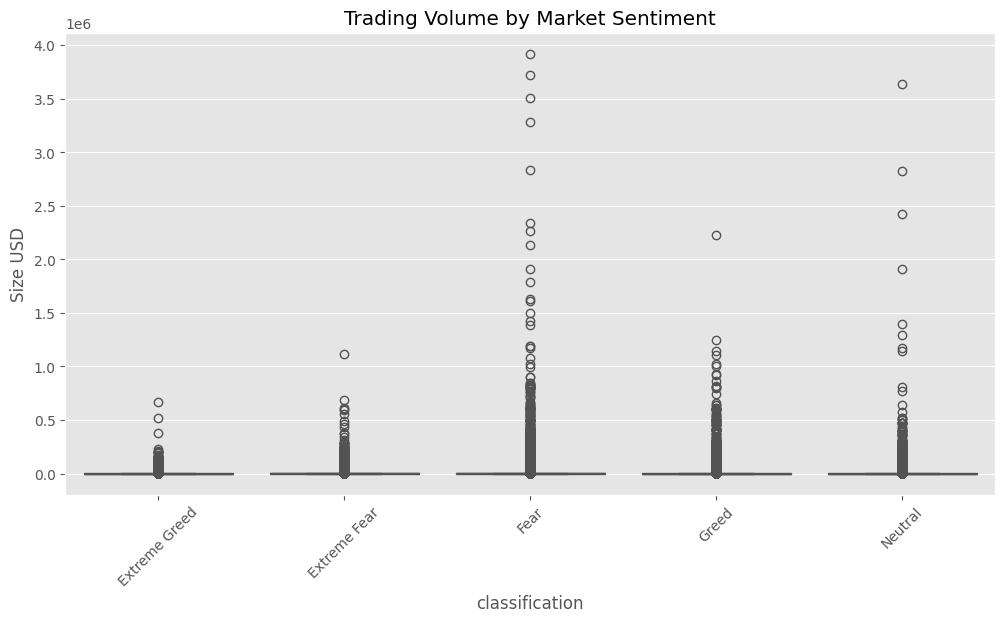

In [62]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Size USD"
)

plt.xticks(rotation=45)
plt.title("Trading Volume by Market Sentiment")
plt.show()

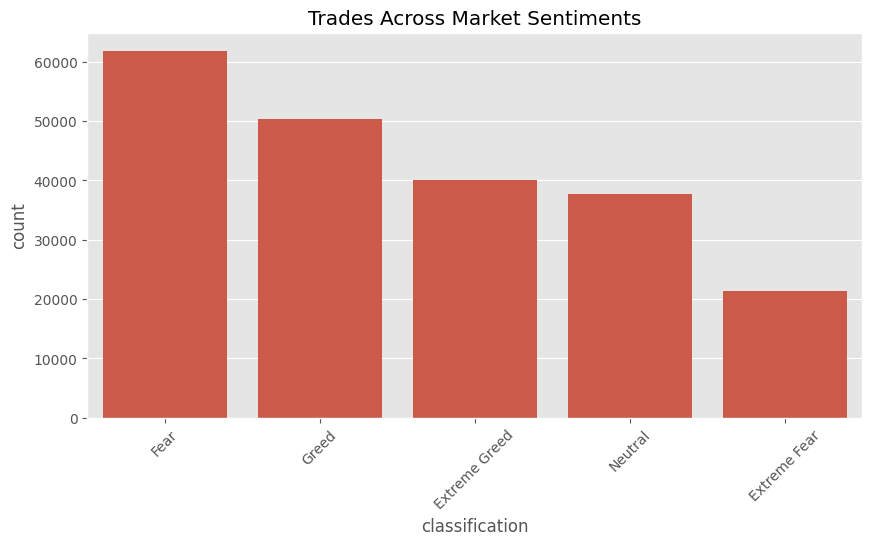

In [63]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Trades Across Market Sentiments")
plt.show()

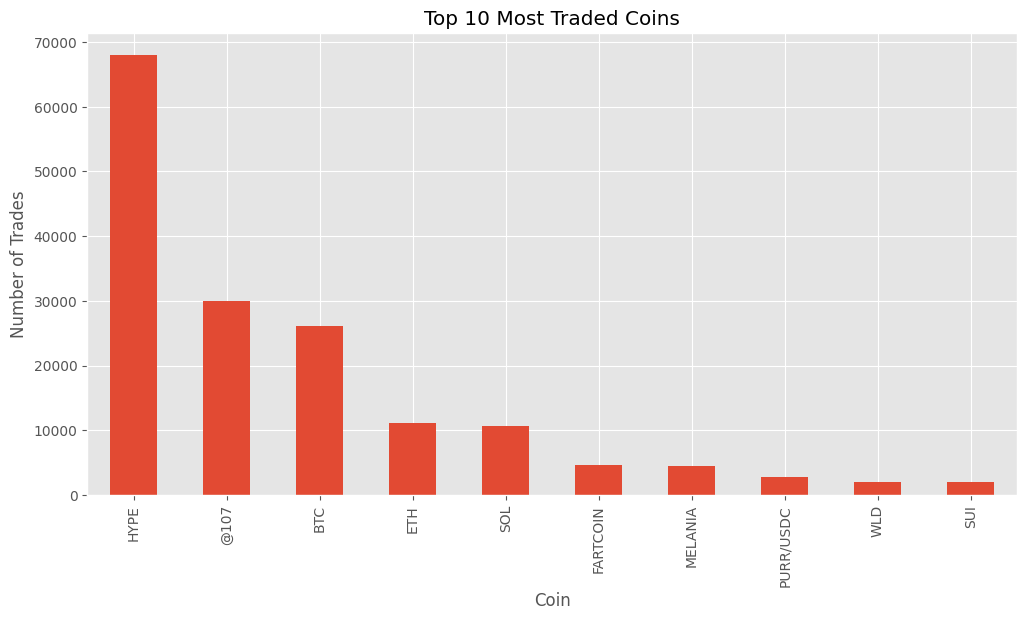

In [64]:
plt.figure(figsize=(12,6))

merged["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.ylabel("Number of Trades")
plt.show()

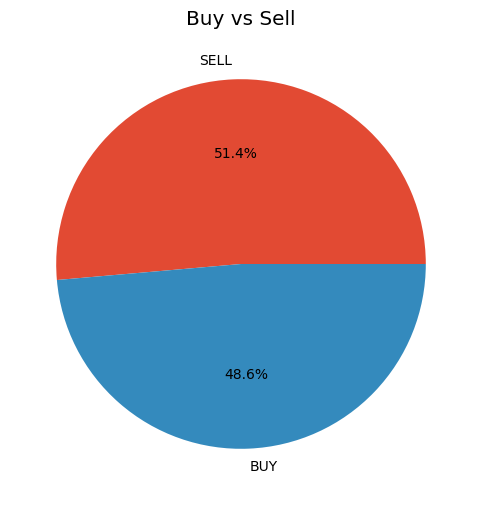

In [65]:
plt.figure(figsize=(6,6))

merged["Side"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Buy vs Sell")
plt.show()

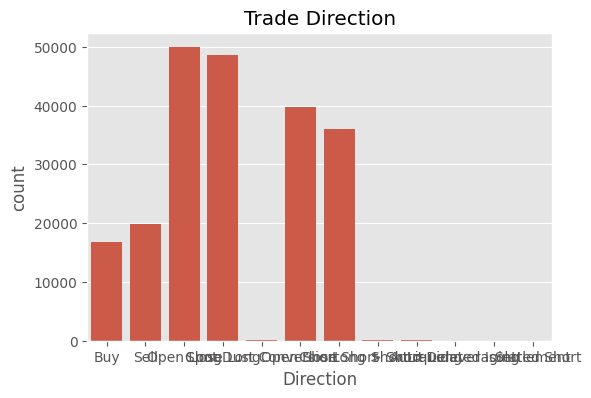

In [66]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=merged,
    x="Direction"
)

plt.title("Trade Direction")
plt.show()

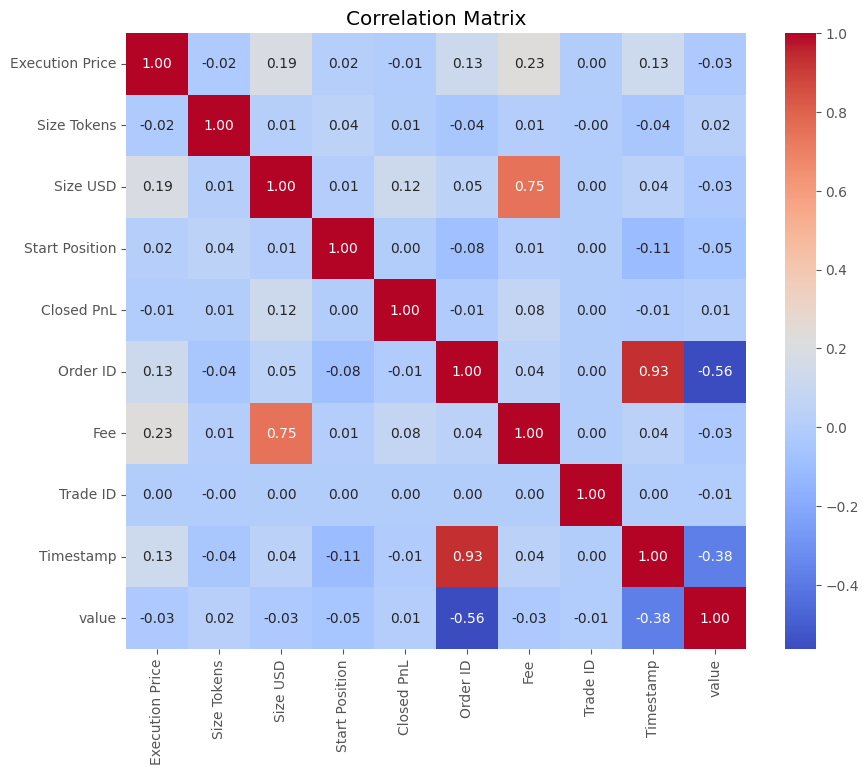

In [67]:
plt.figure(figsize=(10,8))

numeric = merged.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [68]:
profit_by_sentiment = (
    merged.groupby("classification")["Closed PnL"]
    .agg(["count", "mean", "median", "sum"])
    .sort_values("mean", ascending=False)
)

profit_by_sentiment

,count,mean,median,sum
classification,,,,
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Neutral,37686,34.307718,0.0,1.292921e+06


In [69]:
volume_by_sentiment = (
    merged.groupby("classification")["Size USD"]
    .agg(["count", "mean", "sum"])
    .sort_values("sum", ascending=False)
)

volume_by_sentiment

,count,mean,sum
classification,,,
Fear,61837,7816.109931,4.833248e+08
Greed,50303,5736.884375,2.885825e+08
Neutral,37686,4782.732661,1.802421e+08
Extreme Greed,39992,3112.251565,1.244652e+08
Extreme Fear,21400,5349.731843,1.144843e+08


In [70]:
merged["Profit"] = merged["Closed PnL"] > 0

In [71]:
win_rate = (
    merged.groupby("classification")["Profit"]
    .mean()
    .mul(100)
    .round(2)
)

win_rate

classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: Profit, dtype: float64

In [72]:
merged.groupby("classification")["Fee"].mean()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

In [73]:
top_coins = merged["Coin"].value_counts().head(10)

top_coins

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

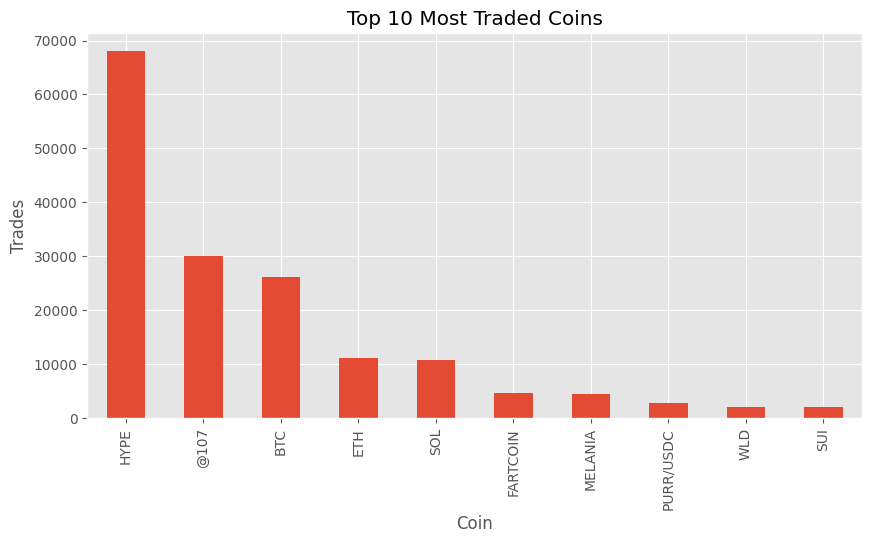

In [74]:
plt.figure(figsize=(10,5))

top_coins.plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Trades")

plt.show()

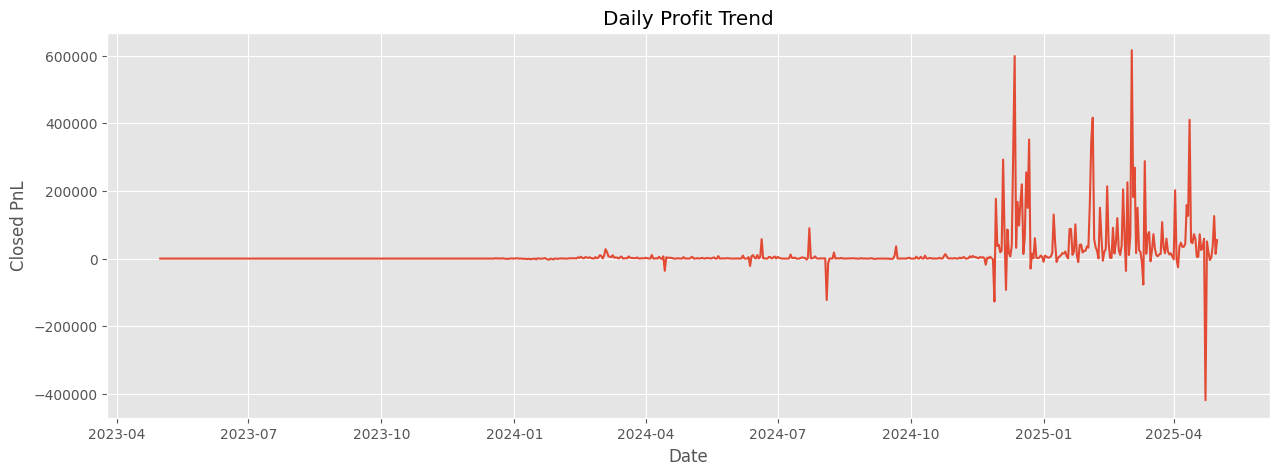

In [75]:
daily_profit = merged.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(15,5))

daily_profit.plot()

plt.title("Daily Profit Trend")
plt.xlabel("Date")
plt.ylabel("Closed PnL")

plt.show()

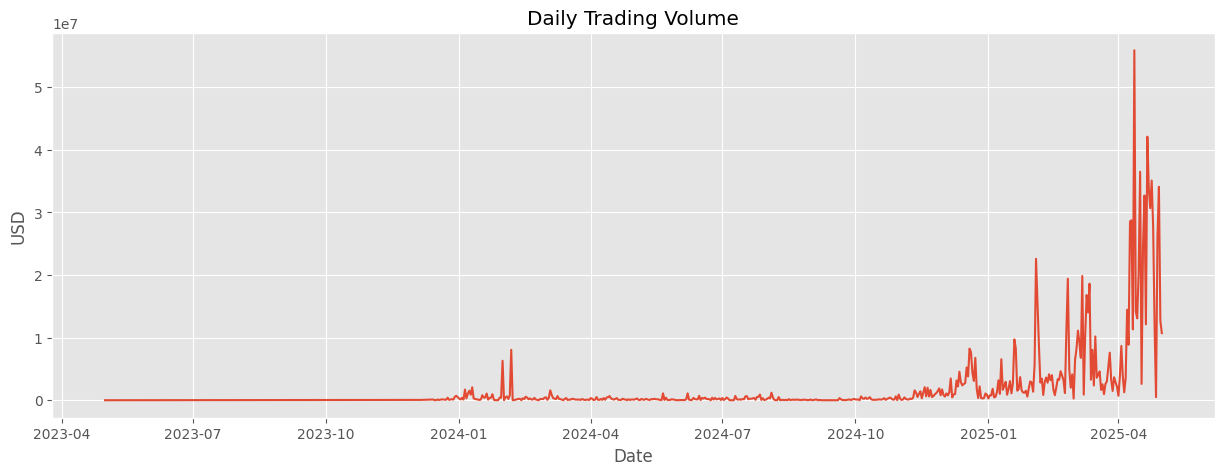

In [76]:
daily_volume = merged.groupby("Date")["Size USD"].sum()

plt.figure(figsize=(15,5))

daily_volume.plot()

plt.title("Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("USD")

plt.show()

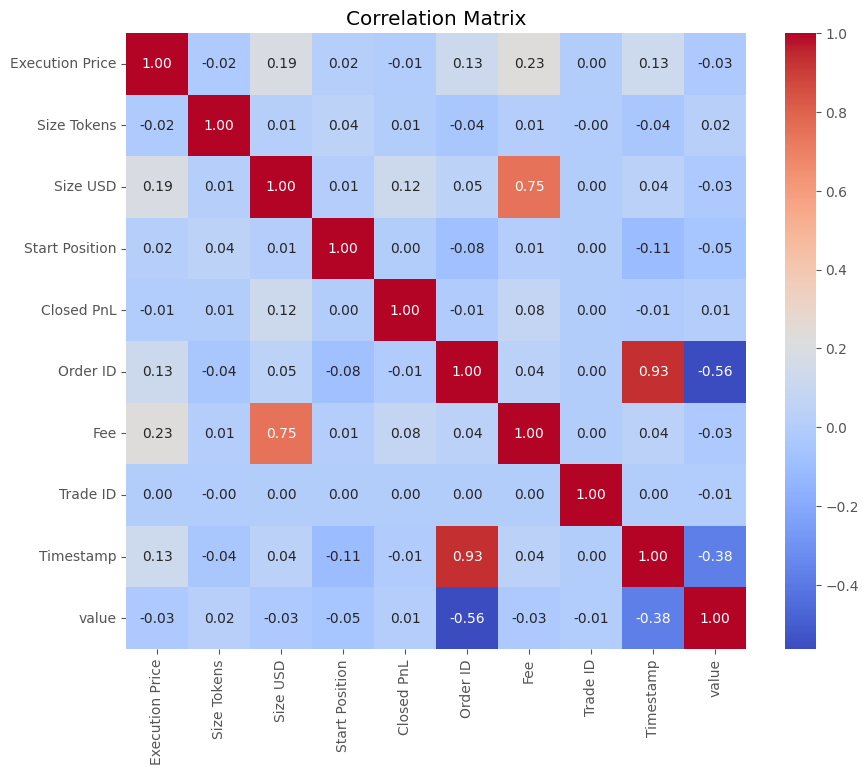

In [77]:
plt.figure(figsize=(10,8))

numeric = merged.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [78]:
merged.to_csv("../outputs/merged_trader_sentiment.csv", index=False)

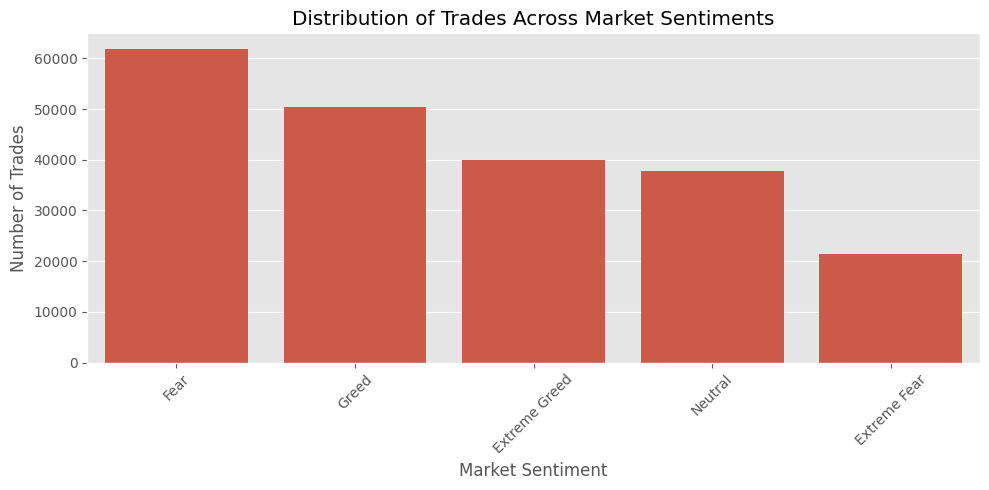

In [79]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Distribution of Trades Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/sentiment_distribution.png", dpi=300)

plt.show()

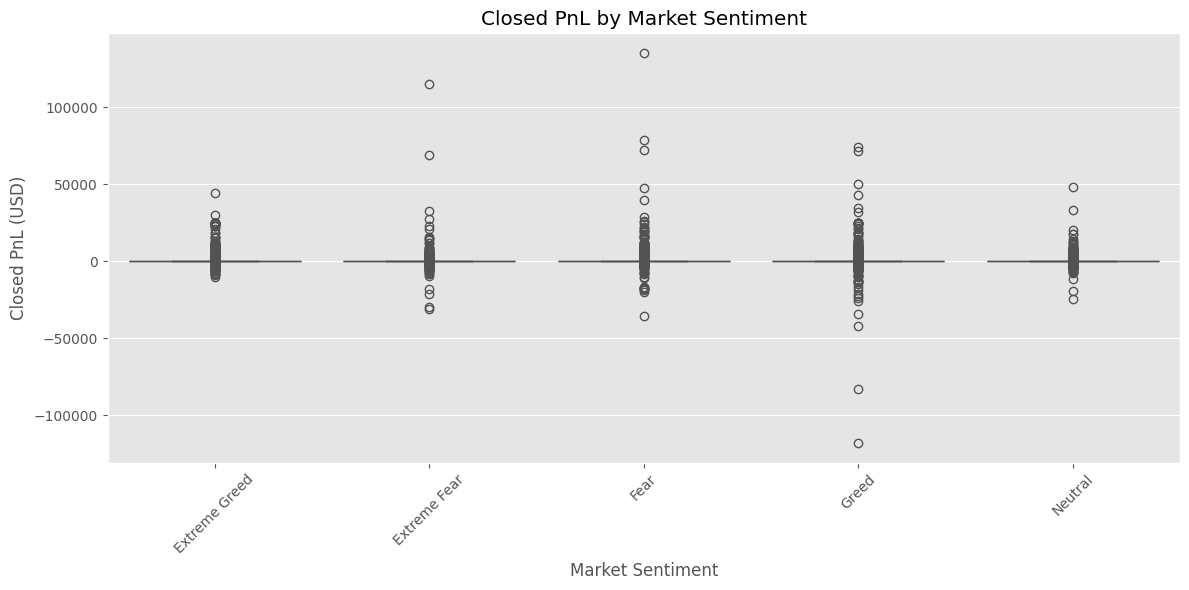

In [80]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL (USD)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/pnl_by_sentiment.png", dpi=300)

plt.show()

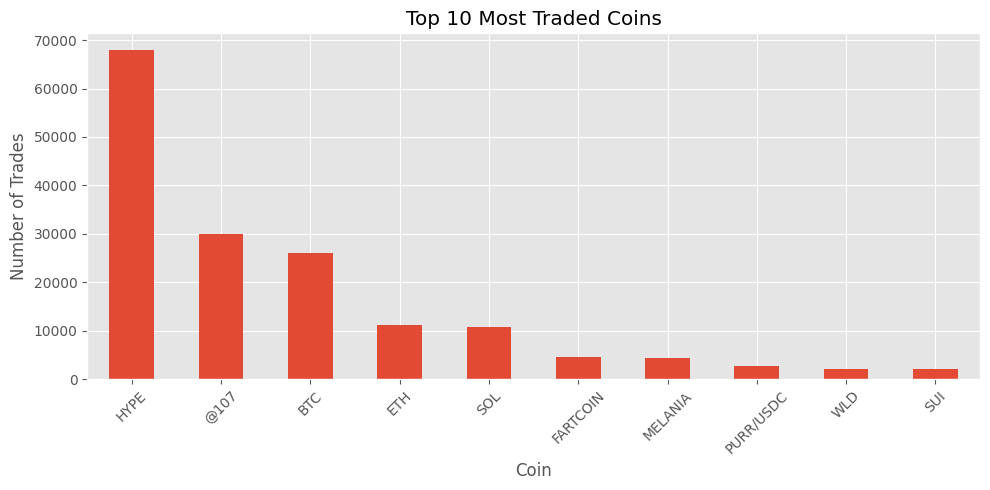

In [81]:
plt.figure(figsize=(10,5))

merged["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/top_10_traded_coins.png", dpi=300)

plt.show()

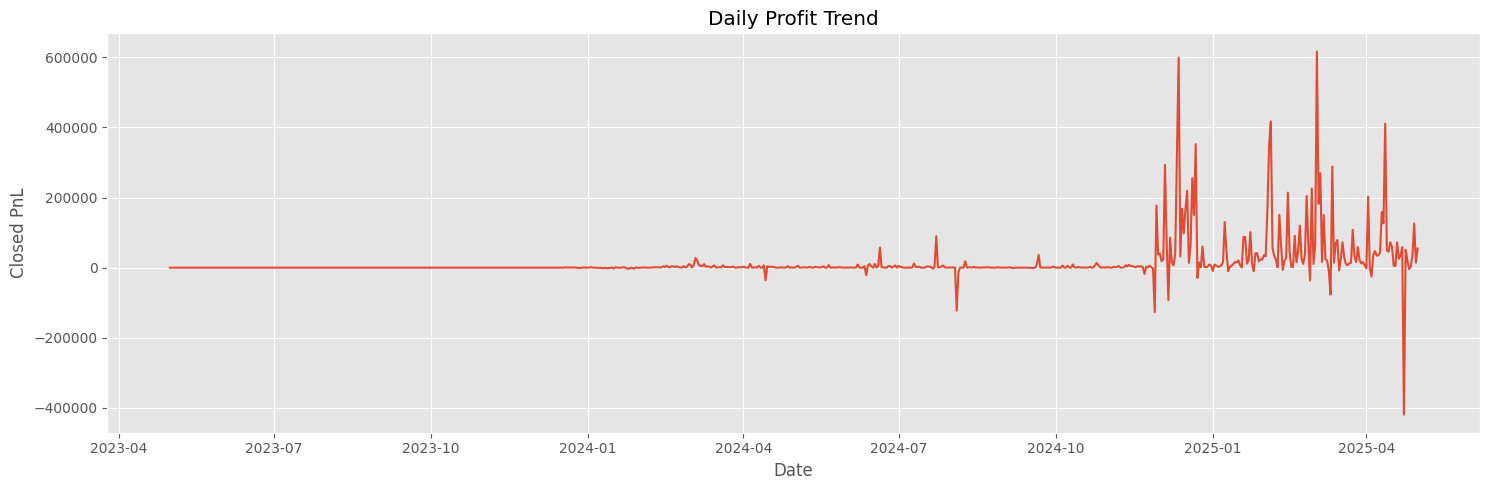

In [82]:
daily_profit = merged.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(15,5))

daily_profit.plot()

plt.title("Daily Profit Trend")
plt.xlabel("Date")
plt.ylabel("Closed PnL")

plt.tight_layout()

plt.savefig("../outputs/daily_profit_trend.png", dpi=300)

plt.show()

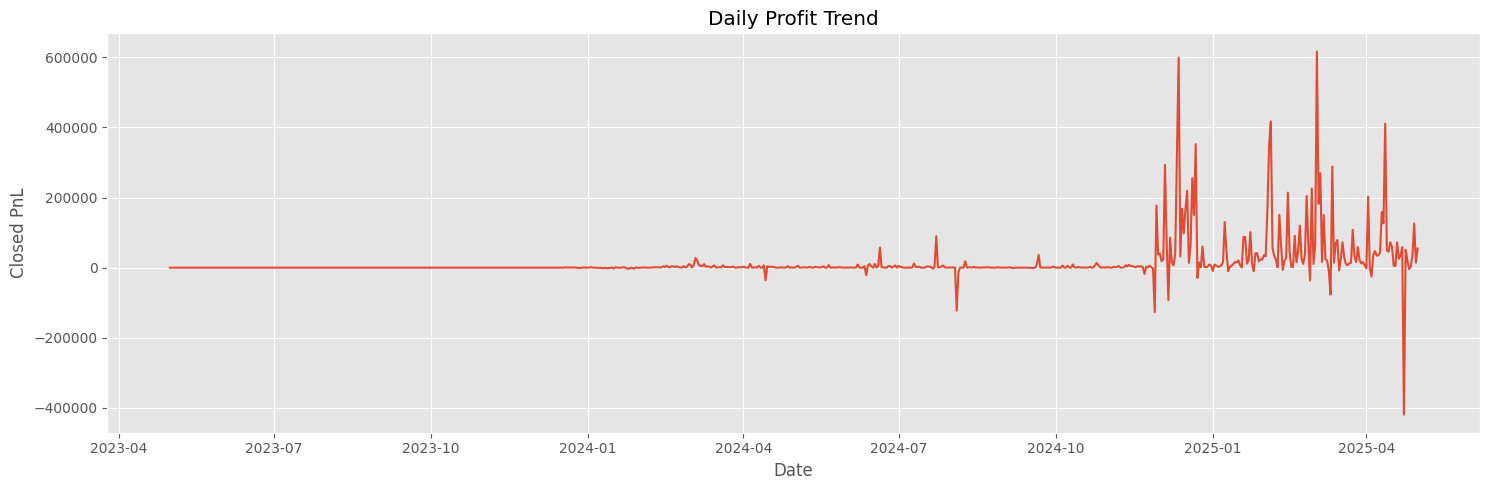

In [83]:
daily_profit = merged.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(15,5))

daily_profit.plot()

plt.title("Daily Profit Trend")
plt.xlabel("Date")
plt.ylabel("Closed PnL")

plt.tight_layout()

plt.savefig("../outputs/daily_profit_trend.png", dpi=300)

plt.show()

In [84]:
profit_by_sentiment.to_csv("../outputs/profit_by_sentiment.csv")

In [85]:
volume_by_sentiment = merged.groupby("classification")["Size USD"].agg(
    Average_Volume="mean",
    Total_Volume="sum"
).round(2)

volume_by_sentiment

,Average_Volume,Total_Volume
classification,,
Extreme Fear,5349.73,1.144843e+08
Extreme Greed,3112.25,1.244652e+08
Fear,7816.11,4.833248e+08
Greed,5736.88,2.885825e+08
Neutral,4782.73,1.802421e+08


In [86]:
volume_by_sentiment.to_csv("../outputs/volume_by_sentiment.csv")

In [87]:
merged["Profitable"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("classification")["Profitable"]
    .mean()
    .mul(100)
    .round(2)
)

win_rate

classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: Profitable, dtype: float64

In [88]:
win_rate.to_csv("../outputs/win_rate.csv")

In [89]:
top_coins = merged["Coin"].value_counts().head(10)

top_coins

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

In [90]:
top_coins.to_csv("../outputs/top_10_coins.csv")

In [91]:
print("Total Trades :", len(merged))
print("Unique Coins :", merged["Coin"].nunique())
print("Total Closed PnL :", round(merged["Closed PnL"].sum(), 2))
print("Average Closed PnL :", round(merged["Closed PnL"].mean(), 2))
print("Average Fee :", round(merged["Fee"].mean(), 4))

Total Trades : 211218
Unique Coins : 246
Total Closed PnL : 10254486.95
Average Closed PnL : 48.55
Average Fee : 1.164


In [92]:
merged.to_csv("../outputs/final_merged_dataset.csv", index=False)